Air Quality Prediction using Machine Learning

Author: Siddhi Malode

Objective:

 Predict air pollution levels using environmental data


## Project Summary

This project predicts air pollution levels using machine learning techniques.
Environmental and sensor data such as NOx, NO2, temperature, and humidity
were used to train a Linear Regression model. The model was evaluated using
standard metrics including MAE, R2 Score, and RMSE.

In [1]:
from google.colab import files
uploaded = files.upload()


Saving AirQualityUCI.zip to AirQualityUCI.zip


## Introduction

Air pollution is a major environmental issue affecting human health worldwide.
This project uses machine learning techniques to predict air quality based on
environmental and sensor data.

In [2]:
import zipfile

with zipfile.ZipFile('AirQualityUCI.zip', 'r') as zip_ref:
    zip_ref.extractall()

## Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load Dataset

In [3]:
import pandas as pd

df = pd.read_csv('AirQualityUCI.csv', sep=';')

df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN


## Data Preprocessing

In [4]:
df = df.replace(',', '.', regex=True)

In [5]:
for col in df.columns:
    if col not in ['Date', 'Time']:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [6]:
import numpy as np

df = df.replace(-200, np.nan)

In [7]:
df = df.fillna(df.mean(numeric_only=True))

## Feature Selection

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9471 non-null   float64
 3   PT08.S1(CO)    9471 non-null   float64
 4   NMHC(GT)       9471 non-null   float64
 5   C6H6(GT)       9471 non-null   float64
 6   PT08.S2(NMHC)  9471 non-null   float64
 7   NOx(GT)        9471 non-null   float64
 8   PT08.S3(NOx)   9471 non-null   float64
 9   NO2(GT)        9471 non-null   float64
 10  PT08.S4(NO2)   9471 non-null   float64
 11  PT08.S5(O3)    9471 non-null   float64
 12  T              9471 non-null   float64
 13  RH             9471 non-null   float64
 14  AH             9471 non-null   float64
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(15), object(2)
memory usage: 1.2+ MB


In [9]:
X = df[['NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']]
y = df['CO(GT)']

## Train Test Split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Building

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Prediction

In [12]:
y_pred = model.predict(X_test)

## Model Evaluation

In [13]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 0.558897737135158
R2 Score: 0.6399203773391101


## Visualization

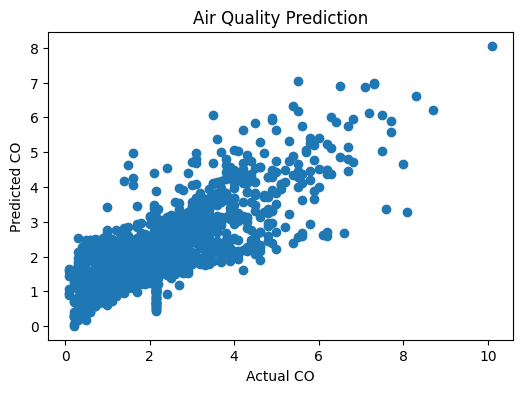

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual CO")
plt.ylabel("Predicted CO")
plt.title("Air Quality Prediction")
plt.show()

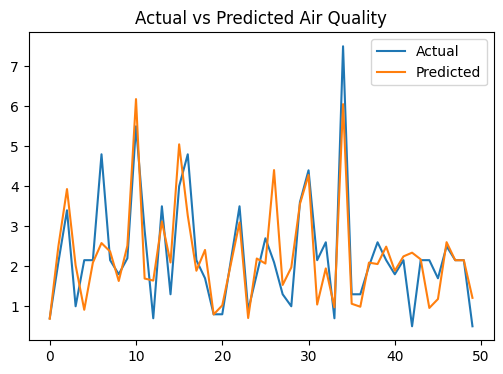

In [15]:
plt.figure(figsize=(6,4))
plt.plot(y_test.values[:50], label="Actual")
plt.plot(y_pred[:50], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Air Quality")
plt.show()

In [16]:
from sklearn.metrics import mean_squared_error

import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 0.797710020897165


## Conclusion

The machine learning model successfully predicts air quality levels using environmental data.
This project demonstrates how machine learning can be applied to environmental monitoring.

## Future Scope

- Apply advanced models such as Random Forest and XGBoost
- Use time-series forecasting for air quality prediction
- Deploy model as web application
- Use deep learning models for improved accuracy